# UCA Performance Across Frequency

This notebook investigates how a fixed physical UCA behaves when the received signal frequency changes.

The antenna positions and spacing remain fixed. For each frequency, the wavelength and corresponding $\lambda/2$ spacing are recalculated. The aim is to see how the beam pattern and direction estimate change as the operating frequency moves away from the original design frequency.

In [26]:
using Plots
using LinearAlgebra
using Statistics

## 1. Fixed UCA Geometry

The physical array is fixed using the geometry chosen at 433 MHz.

The neighbouring antenna spacing is set to $0.4\lambda$ at 433 MHz. Once the array is defined, this spacing remains fixed while the received signal frequency is changed.

In [4]:
# Basic constants
c = 3e8
N = 6

# Reference frequency used to design the physical array
f_ref = 433e6
λ_ref = c / f_ref

# Fixed neighbouring antenna spacing
d = 0.4 * λ_ref

# Radius of the UCA
R = d / (2 * sin(π / N))

# Position of each outer antenna
phi = (0:N-1) .* (2 * π / N)

x = R .* cos.(phi)
y = R .* sin.(phi)

println("Reference frequency = ", f_ref / 1e6, " MHz")
println("Fixed antenna spacing = ", round(d, digits=3), " m")
println("Fixed array radius = ", round(R, digits=3), " m")

Reference frequency = 433.0 MHz
Fixed antenna spacing = 0.277 m
Fixed array radius = 0.277 m


## 2. Compare the Fixed Spacing with $\lambda/2$

The array spacing remains fixed at 0.277 m. As the received frequency changes, the wavelength changes and so does the corresponding $\lambda/2$ spacing.

This comparison gives a simple indication of when the fixed array spacing starts becoming large relative to the received wavelength.

In [5]:
# Frequencies to test
f_test = [200, 250, 300, 350, 400, 433, 450, 500, 550, 600] .* 1e6

# Calculate wavelength and half-wavelength for each frequency
λ_test = c ./ f_test
half_λ = λ_test ./ 2

for i in eachindex(f_test)
    println(round(f_test[i] / 1e6, digits=0), " MHz:  ","λ/2 = ", round(half_λ[i], digits=3), " m")
end

200.0 MHz:  λ/2 = 0.75 m
250.0 MHz:  λ/2 = 0.6 m
300.0 MHz:  λ/2 = 0.5 m
350.0 MHz:  λ/2 = 0.429 m
400.0 MHz:  λ/2 = 0.375 m
433.0 MHz:  λ/2 = 0.346 m
450.0 MHz:  λ/2 = 0.333 m
500.0 MHz:  λ/2 = 0.3 m
550.0 MHz:  λ/2 = 0.273 m
600.0 MHz:  λ/2 = 0.25 m


In [6]:
# Check whether the fixed antenna spacing is within λ/2
for i in eachindex(f_test)

    if d <= half_λ[i]
        status = "Within λ/2"
    else
        status = "Greater than λ/2"
    end

    println(
        round(f_test[i] / 1e6, digits=0), " MHz:  ",
        status
    )
end

200.0 MHz:  Within λ/2
250.0 MHz:  Within λ/2
300.0 MHz:  Within λ/2
350.0 MHz:  Within λ/2
400.0 MHz:  Within λ/2
433.0 MHz:  Within λ/2
450.0 MHz:  Within λ/2
500.0 MHz:  Within λ/2
550.0 MHz:  Greater than λ/2
600.0 MHz:  Greater than λ/2


## 3. UCA Response at Different Frequencies

The transmitter direction is kept fixed while the received frequency is changed.

For each frequency, the steering vector is recalculated using the wavelength at that frequency. The Bartlett response will then show how the fixed physical array behaves across the frequency range.

In [7]:
# True transmitter direction
phi0_deg = 30
phi0 = deg2rad(phi0_deg)

# Horizontal-plane simulation
theta0_deg = 90
theta0 = deg2rad(theta0_deg)

# Angles used for the Bartlett scan
phi_scan_deg = 0:0.1:359.9

println("True transmitter direction = ", phi0_deg, "°")

True transmitter direction = 30°


### Baseline at 433 MHz

The 433 MHz case is used as the baseline because the physical array spacing was originally chosen from this frequency.

The Bartlett response should peak at the true transmitter direction of 30°.

In [8]:
# Use 433 MHz as the baseline frequency
f = 433e6
λ = c / f

# Phase pattern received across the UCA
OD = R .* cos.(phi0 .- phi) .* sin(theta0)
phase = (2 * π / λ) .* OD

received = exp.(im .* phase)

# Calculate the Bartlett response
score = zeros(length(phi_scan_deg))

for k in eachindex(phi_scan_deg)

    phi_test = deg2rad(phi_scan_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test

    steering = exp.(im .* phase_test)

    score[k] = abs(sum(conj.(steering) .* received))
end

# Normalise the response
score = score ./ maximum(score)

phi_est = phi_scan_deg[argmax(score)]

println("Frequency = ", f / 1e6, " MHz")
println("True direction = ", phi0_deg, "°")
println("Estimated direction = ", phi_est, "°")

Frequency = 433.0 MHz
True direction = 30°
Estimated direction = 30.0°


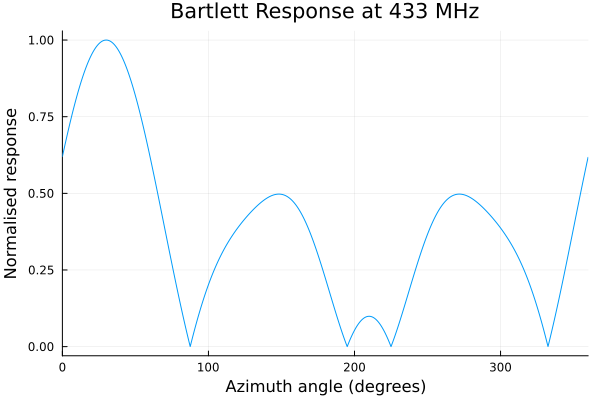

In [9]:
# Plot the normalised Bartlett response
plot(
    phi_scan_deg,
    score,
    xlabel = "Azimuth angle (degrees)",
    ylabel = "Normalised response",
    title = "Bartlett Response at 433 MHz",
    legend = false,
    xlims = (0, 360)
)

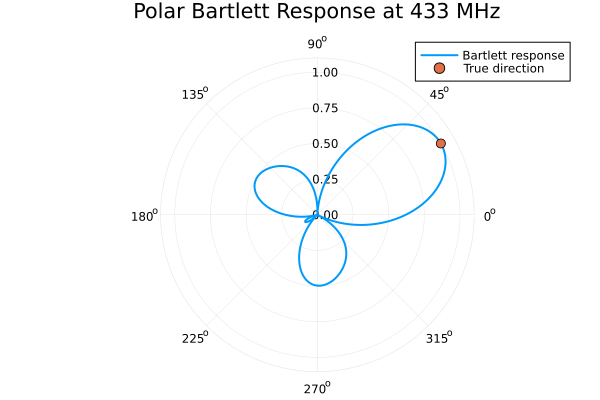

In [10]:
# Plot the Bartlett response on a polar plot
plot(
    deg2rad.(phi_scan_deg),
    score,
    proj = :polar,
    linewidth = 2,
    label = "Bartlett response",
    title = "Polar Bartlett Response at 433 MHz",
    rlims = (0, 1)
)

# Mark the true transmitter direction
scatter!(
    [deg2rad(phi0_deg)],
    [1.0],
    markersize = 5,
    label = "True direction"
)

### Response at 500 MHz

The physical antenna positions are kept unchanged and only the received frequency is increased to 500 MHz.

This allows the effect of the shorter wavelength on the same UCA geometry to be observed.

In [11]:
# Change only the received frequency
f = 500e6
λ = c / f

# Received phase pattern
OD = R .* cos.(phi0 .- phi) .* sin(theta0)
phase = (2 * π / λ) .* OD

received = exp.(im .* phase)

# Bartlett scan
score_500 = zeros(length(phi_scan_deg))

for k in eachindex(phi_scan_deg)

    phi_test = deg2rad(phi_scan_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test

    steering = exp.(im .* phase_test)

    score_500[k] = abs(sum(conj.(steering) .* received))
end

score_500 = score_500 ./ maximum(score_500)

phi_est = phi_scan_deg[argmax(score_500)]

println("Frequency = ", f / 1e6, " MHz")
println("λ/2 = ", round(λ / 2, digits=3), " m")
println("Fixed spacing = ", round(d, digits=3), " m")
println("Estimated direction = ", phi_est, "°")

Frequency = 500.0 MHz
λ/2 = 0.3 m
Fixed spacing = 0.277 m
Estimated direction = 30.0°


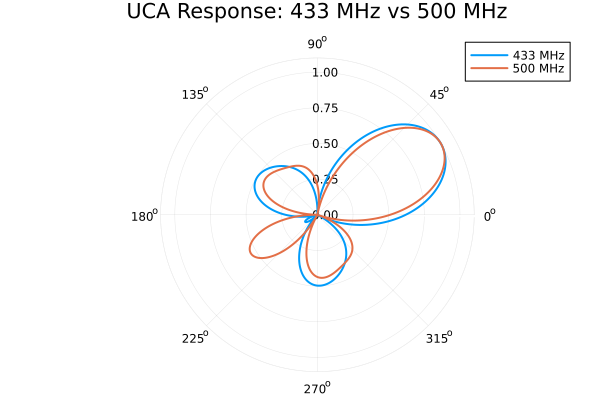

In [12]:
# Compare the polar responses at 433 MHz and 500 MHz

plot(
    deg2rad.(phi_scan_deg),
    score,
    proj = :polar,
    linewidth = 2,
    label = "433 MHz",
    title = "UCA Response: 433 MHz vs 500 MHz",
    rlims = (0, 1)
)

plot!(
    deg2rad.(phi_scan_deg),
    score_500,
    linewidth = 2,
    label = "500 MHz"
)

### Response at 550 MHz

At 550 MHz, the half-wavelength is slightly smaller than the fixed antenna spacing. This case is used to investigate whether stronger spatial ambiguities begin to appear once the spacing exceeds $\lambda/2$.

In [13]:
# Test the array at 550 MHz
f = 550e6
λ = c / f

OD = R .* cos.(phi0 .- phi) .* sin(theta0)
phase = (2 * π / λ) .* OD

received = exp.(im .* phase)

score_550 = zeros(length(phi_scan_deg))

for k in eachindex(phi_scan_deg)

    phi_test = deg2rad(phi_scan_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test

    steering = exp.(im .* phase_test)

    score_550[k] = abs(sum(conj.(steering) .* received))
end

score_550 ./= maximum(score_550)

phi_est = phi_scan_deg[argmax(score_550)]

println("Frequency = ", f / 1e6, " MHz")
println("λ/2 = ", round(λ / 2, digits=3), " m")
println("Fixed spacing = ", round(d, digits=3), " m")
println("Estimated direction = ", phi_est, "°")

Frequency = 550.0 MHz
λ/2 = 0.273 m
Fixed spacing = 0.277 m
Estimated direction = 30.0°


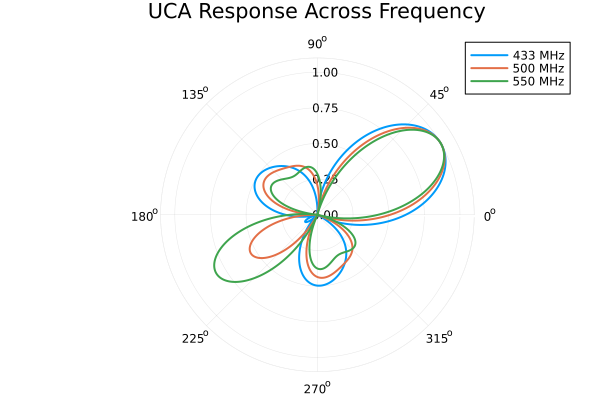

In [14]:
# Compare the three polar responses

plot(
    deg2rad.(phi_scan_deg),
    score,
    proj = :polar,
    linewidth = 2,
    label = "433 MHz",
    title = "UCA Response Across Frequency",
    rlims = (0, 1)
)

plot!(
    deg2rad.(phi_scan_deg),
    score_500,
    linewidth = 2,
    label = "500 MHz"
)

plot!(
    deg2rad.(phi_scan_deg),
    score_550,
    linewidth = 2,
    label = "550 MHz"
)

### Response at 600 MHz

The frequency is increased further to 600 MHz while the physical UCA remains unchanged.

At this frequency, the fixed antenna spacing is clearly greater than $\lambda/2$. The response is examined to see whether the unwanted lobes become more significant.

In [15]:
# Test the array at 600 MHz
f = 600e6
λ = c / f

OD = R .* cos.(phi0 .- phi) .* sin(theta0)
phase = (2 * π / λ) .* OD

received = exp.(im .* phase)

score_600 = zeros(length(phi_scan_deg))

for k in eachindex(phi_scan_deg)

    phi_test = deg2rad(phi_scan_deg[k])

    OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
    phase_test = (2 * π / λ) .* OD_test

    steering = exp.(im .* phase_test)

    score_600[k] = abs(sum(conj.(steering) .* received))
end

score_600 ./= maximum(score_600)

phi_est = phi_scan_deg[argmax(score_600)]

println("Frequency = ", f / 1e6, " MHz")
println("λ/2 = ", round(λ / 2, digits=3), " m")
println("Fixed spacing = ", round(d, digits=3), " m")
println("Estimated direction = ", phi_est, "°")

Frequency = 600.0 MHz
λ/2 = 0.25 m
Fixed spacing = 0.277 m
Estimated direction = 30.0°


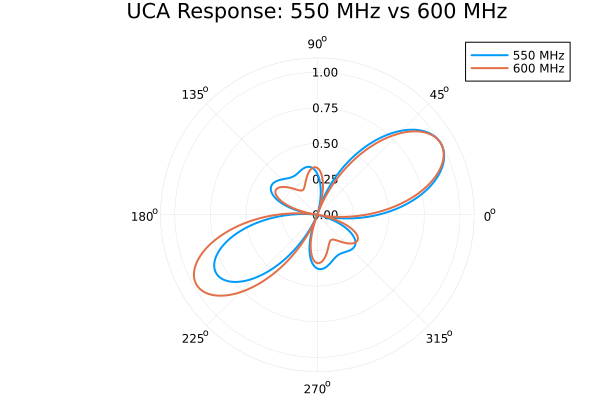

In [16]:
# Compare the higher-frequency responses

plot(
    deg2rad.(phi_scan_deg),
    score_550,
    proj = :polar,
    linewidth = 2,
    label = "550 MHz",
    title = "UCA Response: 550 MHz vs 600 MHz",
    rlims = (0, 1)
)

plot!(
    deg2rad.(phi_scan_deg),
    score_600,
    linewidth = 2,
    label = "600 MHz"
)

### Strongest Incorrect Peak

The correct direction may still give the largest Bartlett response even when a strong competing lobe is present.

The strongest incorrect local peak is therefore identified and compared with the main peak. A smaller separation means that the direction estimate is becoming more ambiguous.

In [17]:
# Find local peaks in the Bartlett response
is_peak = (score_600 .> circshift(score_600, 1)) .&
          (score_600 .> circshift(score_600, -1))

peak_indices = findall(is_peak)

# Find the true main peak
main_index = argmax(score_600)

# Remove the main peak from the list
side_indices = filter(i -> i != main_index, peak_indices)

# Find the strongest remaining peak
side_index = side_indices[argmax(score_600[side_indices])]

main_angle = phi_scan_deg[main_index]
side_angle = phi_scan_deg[side_index]

main_level = score_600[main_index]
side_level = score_600[side_index]

SLL_dB = 20 * log10(main_level / side_level)

println("Main peak = ", main_angle, "°")
println("Strongest incorrect peak = ", side_angle, "°")
println("Incorrect peak level = ", round(side_level, digits=3))
println("Peak separation = ", round(SLL_dB, digits=2), " dB")

Main peak = 30.0°
Strongest incorrect peak = 210.0°
Incorrect peak level = 0.979
Peak separation = 0.18 dB


## 4. Peak Separation Across Frequency

The strongest incorrect peak is compared with the correct Bartlett peak at each test frequency.

A large separation indicates that the correct direction is clearly distinguishable. As the separation approaches 0 dB, the array becomes increasingly ambiguous because an incorrect direction produces almost the same response as the true direction.

In [18]:
# Store the strongest incorrect peak separation for each frequency
peak_separation_dB = zeros(length(f_test))

for i in eachindex(f_test)

    f = f_test[i]
    λ = c / f

    # Received phase pattern for the true transmitter direction
    OD = R .* cos.(phi0 .- phi) .* sin(theta0)
    phase = (2 * π / λ) .* OD

    received = exp.(im .* phase)

    # Bartlett scan for this frequency
    score_temp = zeros(length(phi_scan_deg))

    for k in eachindex(phi_scan_deg)

        phi_test = deg2rad(phi_scan_deg[k])

        OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
        phase_test = (2 * π / λ) .* OD_test

        steering = exp.(im .* phase_test)

        score_temp[k] = abs(sum(conj.(steering) .* received))
    end

    score_temp ./= maximum(score_temp)

    # Find all local peaks
    is_peak = (score_temp .> circshift(score_temp, 1)) .&
              (score_temp .> circshift(score_temp, -1))

    peak_indices = findall(is_peak)

    # Separate the correct peak from the strongest incorrect peak
    main_index = argmax(score_temp)
    side_indices = filter(j -> j != main_index, peak_indices)

    # Check whether there is another local peak
if isempty(side_indices)

    peak_separation_dB[i] = NaN

else

    side_index = side_indices[argmax(score_temp[side_indices])]

    peak_separation_dB[i] =
        20 * log10(score_temp[main_index] / score_temp[side_index])

end

    println(
        round(f / 1e6, digits=0), " MHz: ",
        peak_separation_dB[i]
    )
end

200.0 MHz: NaN
250.0 MHz: 13.72095998004295
300.0 MHz: 8.897373233495642
350.0 MHz: 6.835480966813688
400.0 MHz: 6.067247270169989
433.0 MHz: 6.063770738245814
450.0 MHz: 6.19708421535628
500.0 MHz: 5.361166842887018
550.0 MHz: 1.7302246240081909
600.0 MHz: 0.18359413080992193


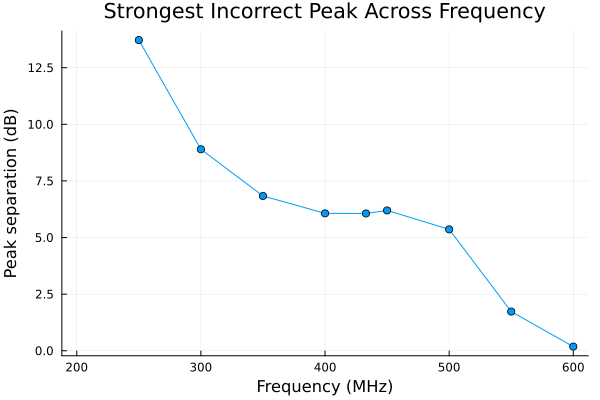

In [19]:
# Plot the separation between the correct and strongest incorrect peak

plot(
    f_test ./ 1e6,
    peak_separation_dB,
    marker = :circle,
    xlabel = "Frequency (MHz)",
    ylabel = "Peak separation (dB)",
    title = "Strongest Incorrect Peak Across Frequency",
    legend = false
)

## 5. Main-Lobe Width Across Frequency

At lower frequencies, the physical array becomes smaller relative to the wavelength. This reduces the angular discrimination of the array.

The half-power beamwidth (HPBW) is therefore calculated at each test frequency to show how the main-lobe width changes across the operating range.

In [20]:
# Store the half-power beamwidth for each frequency
HPBW_deg = zeros(length(f_test))

half_power = 1 / sqrt(2)

for i in eachindex(f_test)

    f = f_test[i]
    λ = c / f

    # Received phase pattern
    OD = R .* cos.(phi0 .- phi) .* sin(theta0)
    phase = (2 * π / λ) .* OD

    received = exp.(im .* phase)

    # Bartlett response
    score_temp = zeros(length(phi_scan_deg))

    for k in eachindex(phi_scan_deg)

        phi_test = deg2rad(phi_scan_deg[k])

        OD_test = R .* cos.(phi_test .- phi) .* sin(theta0)
        phase_test = (2 * π / λ) .* OD_test

        steering = exp.(im .* phase_test)

        score_temp[k] = abs(sum(conj.(steering) .* received))
    end

    score_temp ./= maximum(score_temp)

    # Find the main peak
    main_index = argmax(score_temp)

    # Move left and right until the response falls below half power
    left_index = main_index
    while score_temp[left_index] >= half_power
        left_index = mod1(left_index - 1, length(score_temp))
    end

    right_index = main_index
    while score_temp[right_index] >= half_power
        right_index = mod1(right_index + 1, length(score_temp))
    end

    # Calculate the circular beamwidth
    HPBW_deg[i] = mod(phi_scan_deg[right_index] - phi_scan_deg[left_index], 360)

    println(
        round(f / 1e6, digits=0), " MHz: ",
        round(HPBW_deg[i], digits=1), "°"
    )
end

200.0 MHz: 116.2°
250.0 MHz: 91.4°
300.0 MHz: 75.6°
350.0 MHz: 64.4°
400.0 MHz: 56.2°
433.0 MHz: 51.8°
450.0 MHz: 50.0°
500.0 MHz: 44.8°
550.0 MHz: 40.8°
600.0 MHz: 37.4°


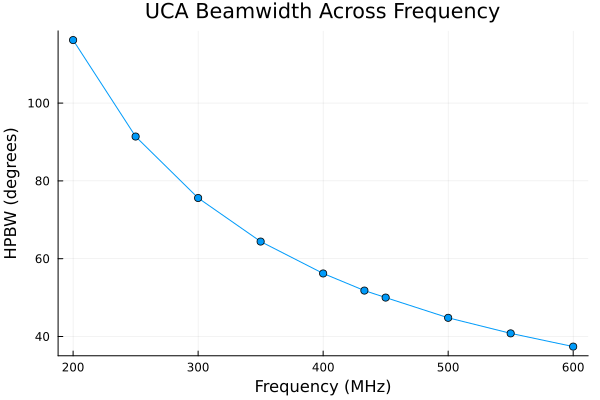

In [21]:
# Plot how the main-lobe width changes with frequency

plot(
    f_test ./ 1e6,
    HPBW_deg,
    marker = :circle,
    xlabel = "Frequency (MHz)",
    ylabel = "HPBW (degrees)",
    title = "UCA Beamwidth Across Frequency",
    legend = false
)

## Summary

A fixed six-element UCA with neighbouring antenna spacing of approximately 0.277 m was evaluated over different received frequencies.

At lower frequencies, the main beam became wider, reducing angular resolution. At higher frequencies, the main beam became narrower but stronger competing lobes developed. The ideal simulations suggest a useful range of approximately 300–500 MHz, while a more conservative practical test range of about 350–450 MHz is considered more reasonable for later hardware testing.

The array geometry will therefore remain fixed, while the steering model will use the wavelength corresponding to the received frequency.